---
title: 'Chapter 2: Forecasting Principles and Methods'
jupyter:
  kernelspec:
    display_name: Python (timeSeries-course)
    language: python
    name: timeseries-course
editor_options: 
  chunk_output_type: console
---

## Forecasting Principles and Methods

### Topics Covered:

1.  The Forecasting Workflow

2.  Benchmark Forecasting Methods

3.  Residual Diagnostics - Model validation

4.  Prediction Intervals

5.  Metrics to Evaluate Forecasting Performance

6.  Validation Strategies

------------------------------------------------------------------------

## 1. The Forecasting Workflow

Forecasting is a structured process that goes beyond simply fitting a model. The workflow for forecasting follows the following steps:

1.  **Data preparation:** Loading and formatting data (e.g., handling timestamps, dealing with missing data, and other pre-processing task, ...)

2.  **Visualization:** Plotting data to identify patterns (trend, seasonality, cycles, ...)

3.  **Model specification:** Defining the time series model structure

4.  **Estimation:** Training the model parameters on historical data

5.  **Evaluation:** Checking model validity and accuracy metrics on test sets

6.  **Forecasting:** Producing future values with prediction intervals

------------------------------------------------------------------------

## 2. Benchmark Forecasting Methods

Some forecasting methods are very simple but sometimes surprisingly effective. Additionally, they often serve as effective benchmarks to be compared with other more sophisticated method. For instance, any other complex model (like ARIMA) must outperform these baselines to be considered useful. In this section we will use the `Darts` library that provides many forecasting models including ARIMA, machine learning models, deep learning models and also simple models for benchmaking. This library uses its own data type (`TimeSeries`) form time series. Alternatively, we use also `sktime` which includes many interesting features and use `pandas` data structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from darts import TimeSeries

# Load h2o data (monthly measurements)
data = fetch_dataset(name='h2o', raw=True)
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')

# data in TimeSeries format for darts
y =TimeSeries.from_dataframe(data, time_col='fecha', value_cols='x', freq='MS')

# data in pandas format for sktime
data = data.set_index('fecha')
y_skt = data['x'].to_period('M') 

╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 2 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

### 2.1. Mean Method

The forecast for all future values is equal to the mean of the historical data ${y_1,\ldots,y_T}$.

$$
\hat{y}_{T+h|T} = \bar{y} = \frac{1}{T}\sum_{t=1}^{T}y_{t}
$$

**Python code using `Darts` package:**

Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


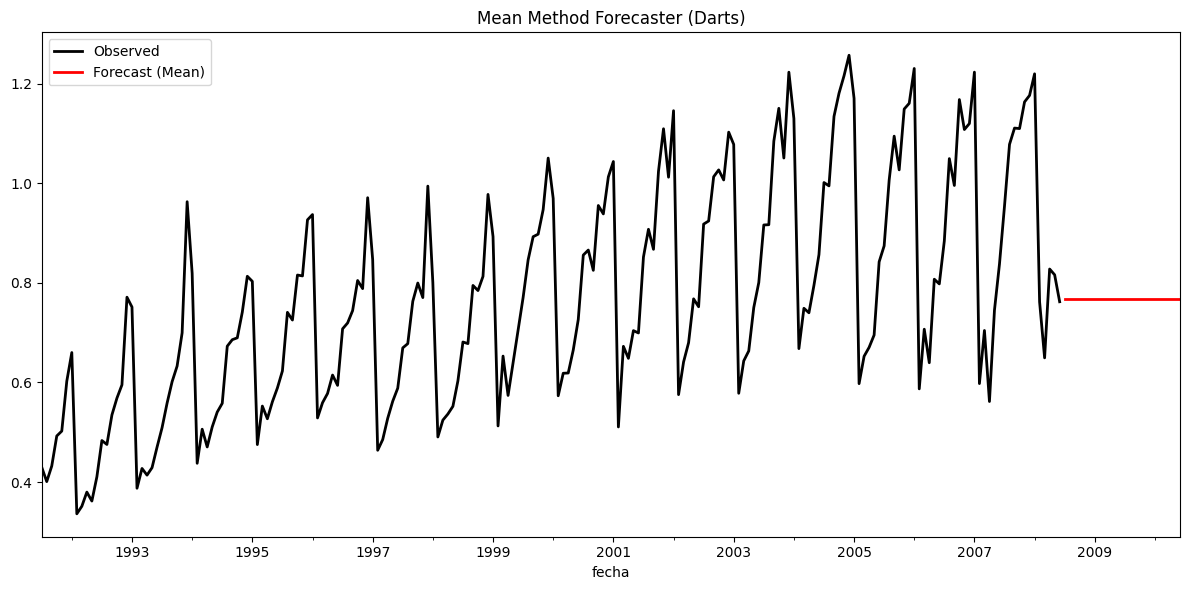

In [2]:
# 2.1. Forecasting using the Mean Method (Darts implementation)
from darts.models import NaiveMean
# Initialize the NaiveMean model
model = NaiveMean()
# Fit the model to the historical series
model.fit(y)
# Generate predictions for the next 'h' time steps
h = 24 # Forecast 2 years ahead
forecast = model.predict(h)
forecast.head()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
# Observed values in black (Dart implements its own internal plot method)
y.plot(label='Observed', color='black')
# Forecasted values in red
forecast.plot(label='Forecast (Mean)', color='red')
plt.title("Mean Method Forecaster (Darts)")
plt.legend()
plt.tight_layout()
plt.show()

**Python code using `sktime` package:**

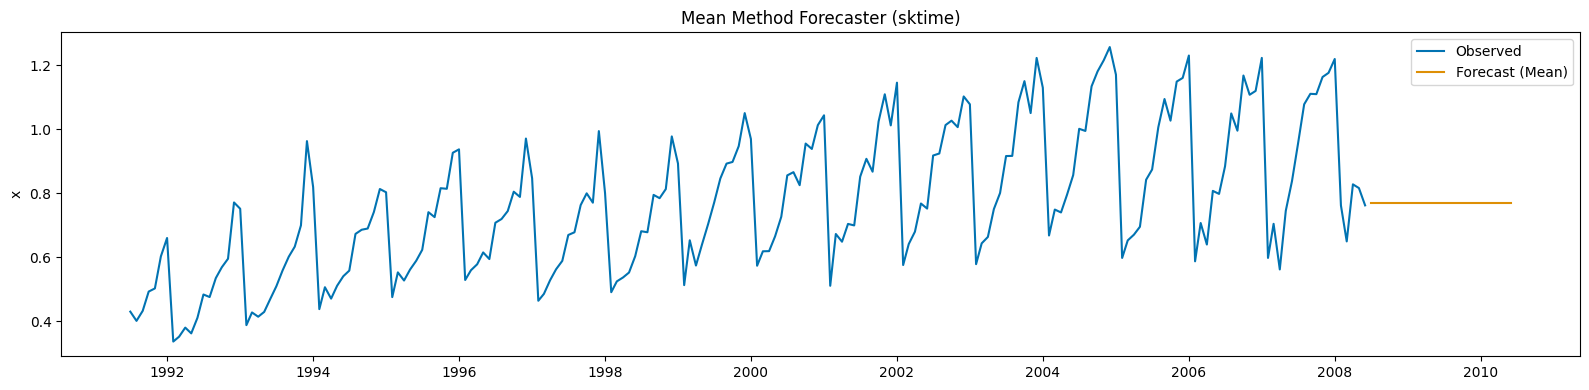

In [3]:
# 2.1. Forecasting using the Mean Method (sktime implementation)
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# # Initialize the NaiveMean model
model = NaiveForecaster(strategy="mean")

# Fit the model to the historical series
model.fit(y_skt)

# Generate predictions for the next 'h' time steps
h = 24 # Forecast 2 years ahead
# ForecastingHorizon creates the sequence [1, 2, ..., 24] relative to the last training point
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
# Generate predictions
forecast = model.predict(fh)


# Plot using plot series
fig, ax = plot_series(
    y_skt,              # historical data
    forecast,           # forecasting
    labels=["Observed", "Forecast (Mean)"], # labels for the plotted time series
    markers=[None,None]  # markers for the time series (None= no markers, only line)
)

plt.title("Mean Method Forecaster (sktime)")
plt.tight_layout()
plt.show()

### 2.2. Naïve Method

The forecast is set to be the value of the last observation. This is optimal when data follow a random walk processes. The method is also known as random walk forecast.

$$
\hat{y}_{T+h|T} = y_{T}
$$

**Python code using `Darts` package:**

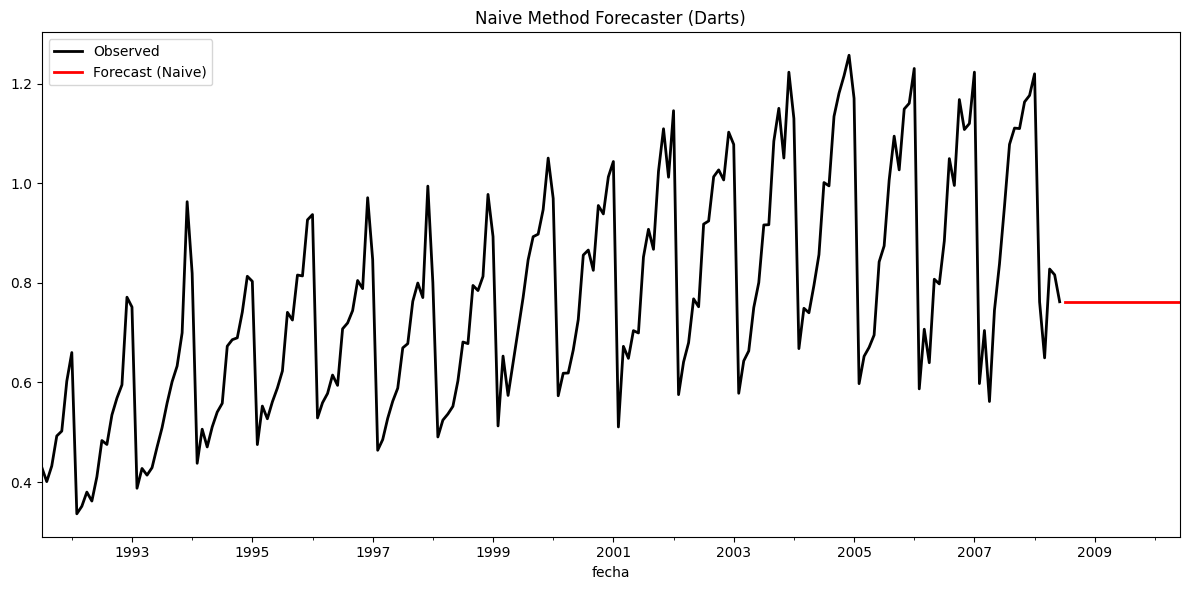

In [4]:
# 2.2. Forecasting using the Naive Method (Darts implementation)
from darts.models import NaiveSeasonal
# Initialize the NaiveMean model (equivalent to meanf in R or y.mean() logic)
model = NaiveSeasonal(K=1)
# Fit the model to the historical series
h = 24 # Forecast 2 years ahead
model.fit(y)
# Generate predictions for the next 'h' time steps
# Darts handles the future date generation automatically
forecast = model.predict(h)
forecast.head()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
# Observed values in black (Dart implements its own internal plot method)
y.plot(label='Observed', color='black')
# Forecasted values in red
forecast.plot(label='Forecast (Naive)', color='red')
plt.title("Naive Method Forecaster (Darts)")
plt.legend()
plt.tight_layout()
plt.show()

**Python code using `sktime` package:**

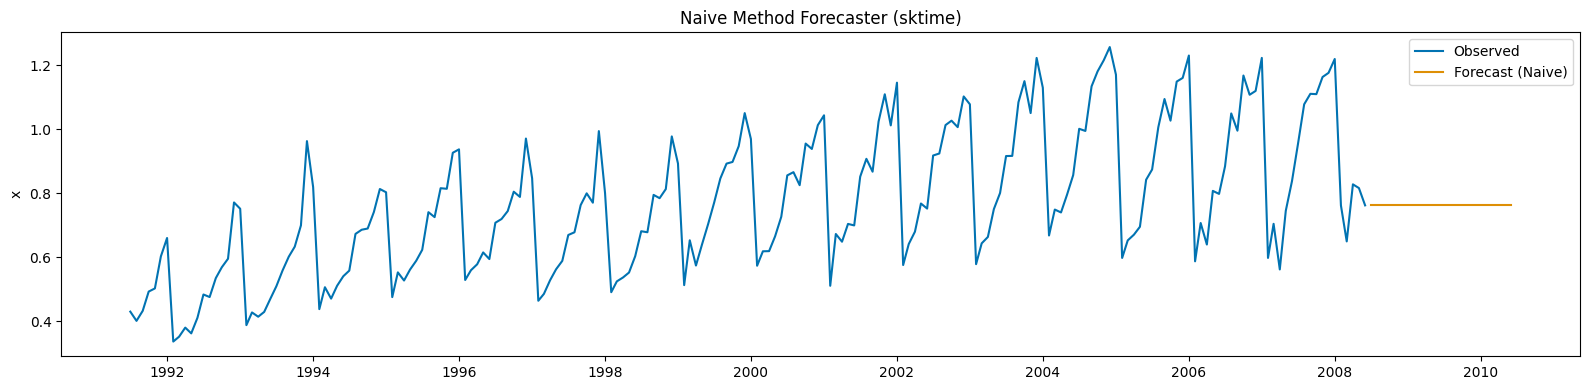

In [5]:
# 2.2. Forecasting using the Naive Method (sktime implementation)
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# # Initialize the Naive model
model = NaiveForecaster(strategy="last")

# Fit the model to the historical series
model.fit(y_skt)

# Generate predictions for the next 'h' time steps
h = 24 # Forecast 2 years ahead
# ForecastingHorizon creates the sequence [1, 2, ..., 24] relative to the last training point
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
# Generate predictions
forecast = model.predict(fh)


# Plot using plot series
fig, ax = plot_series(
    y_skt,              # historical data
    forecast,           # forecasting
    labels=["Observed", "Forecast (Naive)"], # labels for the plotted time series
    markers=[None,None]  # markers for the time series (None= no markers, only line)
)

plt.title("Naive Method Forecaster (sktime)")
plt.tight_layout()
plt.show()

### 2.3. Seasonal Naïve Method

Useful for highly seasonal data. We set each forecast to be equal to the last observed value from the same season of the year (e.g. the same month of the previous year).

$$
\hat{y}_{T+h|T} = y_{T+h-m(k+1)}
$$

where $m$ is the seasonal period (e.g., 12 for monthly data) and $k$ is the integer part of $(h-1)/m$.

**Python code using `Darts` package:**

╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 2 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

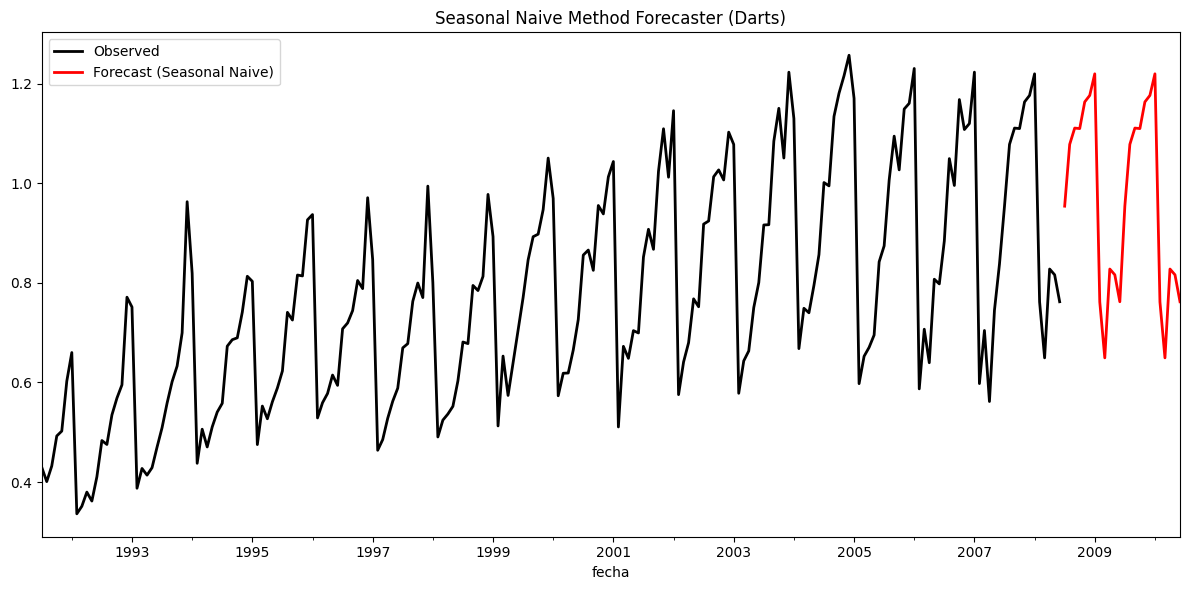

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from darts import TimeSeries

# Load h2o data (monthly measurements)
data = fetch_dataset(name='h2o', raw=True)
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
y =TimeSeries.from_dataframe(data, time_col='fecha', value_cols='x', freq='MS')

# 2.3. Forecasting using the Seasonal Naive Method (Darts implementation)
from darts.models import NaiveSeasonal
# Initialize the NaiveMean model (equivalent to meanf in R or y.mean() logic)
m=12 #seasonal period (monthly data)
model = NaiveSeasonal(K=m)
# Fit the model to the historical series
h = 24 # Forecast 2 years ahead
model.fit(y)
# Generate predictions for the next 'h' time steps
# Darts handles the future date generation automatically
forecast = model.predict(h)
forecast.head()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
# Observed values in black (Dart implements its own internal plot method)
y.plot(label='Observed', color='black')
# Forecasted values in red
forecast.plot(label='Forecast (Seasonal Naive)', color='red')
plt.title("Seasonal Naive Method Forecaster (Darts)")
plt.legend()
plt.tight_layout()
plt.show()

**Python code using `sktime` package:**

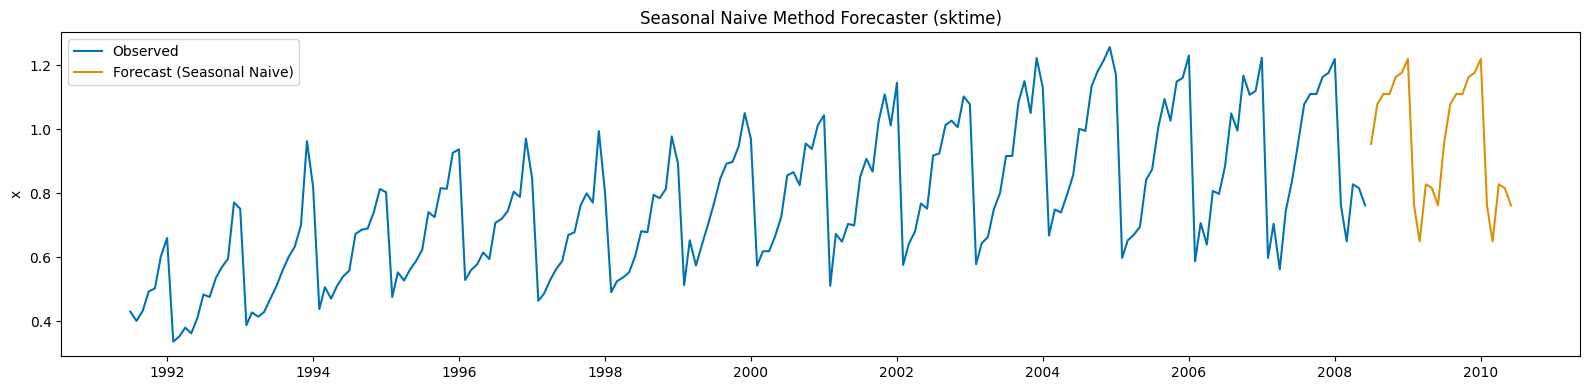

In [7]:
# 2.3. Forecasting using the Seasonal Naive Method (sktime implementation)
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# # Initialize the Naive model
m=12 # time period: monthly
model = NaiveForecaster(strategy="last", sp=m)

# Fit the model to the historical series
model.fit(y_skt)

# Generate predictions for the next 'h' time steps
h = 24 # Forecast 2 years ahead
# ForecastingHorizon creates the sequence [1, 2, ..., 24] relative to the last training point
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
# Generate predictions
forecast = model.predict(fh)


# Plot using plot series
fig, ax = plot_series(
    y_skt,              # historical data
    forecast,           # forecasting
    labels=["Observed", "Forecast (Seasonal Naive)"], # labels for the plotted time series
    markers=[None,None]  # markers for the time series (None= no markers, only line)
)

plt.title("Seasonal Naive Method Forecaster (sktime)")
plt.tight_layout()
plt.show()

### 2.4. Drift Method

A variation of the naïve method that allows the forecast to increase or decrease over time based on the average historical change (also known as drift):

$$
\hat{y}_{T+h|T} = y_{T} + \frac{h}{T-1} \sum_{t=2}^{T}(y_{t}-y_{t-1}) = y_{T} + h \left( \frac{y_{T}-y_{1}}{T-1} \right)
$$

**Python code using `Darts` package:**

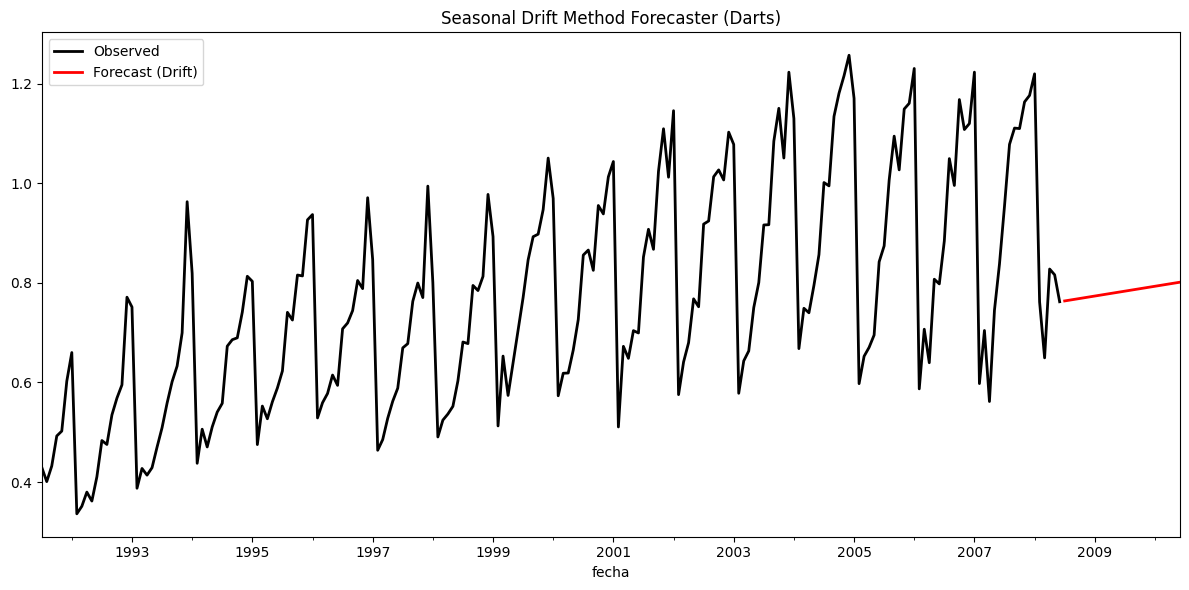

In [8]:
# 2.4. Forecasting using the Drift Method (Darts implementation)
from darts.models import NaiveDrift
# Initialize the model
model = NaiveDrift()
# Fit the model to the historical series
h = 24 # Forecast 2 years ahead
model.fit(y)
# Generate predictions for the next 'h' time steps
# Darts handles the future date generation automatically
forecast = model.predict(h)
forecast.head()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
# Observed values in black (Dart implements its own internal plot method)
y.plot(label='Observed', color='black')
# Forecasted values in red
forecast.plot(label='Forecast (Drift)', color='red')
plt.title("Seasonal Drift Method Forecaster (Darts)")
plt.legend()
plt.tight_layout()
plt.show()

**Python code using `sktime` package:**

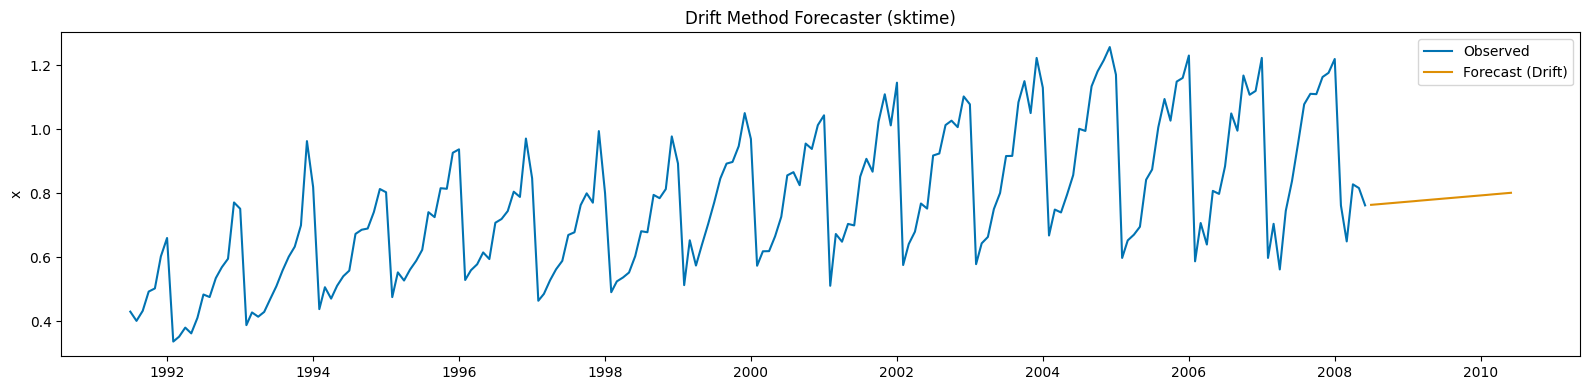

In [9]:
# 2.4. Forecasting using the Drift Method (sktime implementation)
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# # Initialize the Naive model
m=12 # time period: monthly
model = NaiveForecaster(strategy="drift")

# Fit the model to the historical series
model.fit(y_skt)

# Generate predictions for the next 'h' time steps
h = 24 # Forecast 2 years ahead
# ForecastingHorizon creates the sequence [1, 2, ..., 24] relative to the last training point
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
# Generate predictions
forecast = model.predict(fh)


# Plot using plot series
fig, ax = plot_series(
    y_skt,              # historical data
    forecast,           # forecasting
    labels=["Observed", "Forecast (Drift)"], # labels for the plotted time series
    markers=[None,None]  # markers for the time series (None= no markers, only line)
)

plt.title("Drift Method Forecaster (sktime)")
plt.tight_layout()
plt.show()

## 3. Residual Diagnostics - Model validation

Residuals are defined as the difference between the observations and the corresponding fitted values by a time series model:

$e_{t} = y_{t} - \hat{y}_{t|t-1}$

If a data transformation has been used in the model, then it is often useful to look at residuals on the transformed scale. These are called *innovation residuals*. E.g. Assume data is transformed using logarithms ($w_t = log(y_t)$). Then innovation residuals are given by $w_t - \hat{w}_t$ while regular residuals are given by $y_t - \hat{y}_t$. If no transformation is used innovation residuals are the same as regular residuals, and the are simply called residuals.

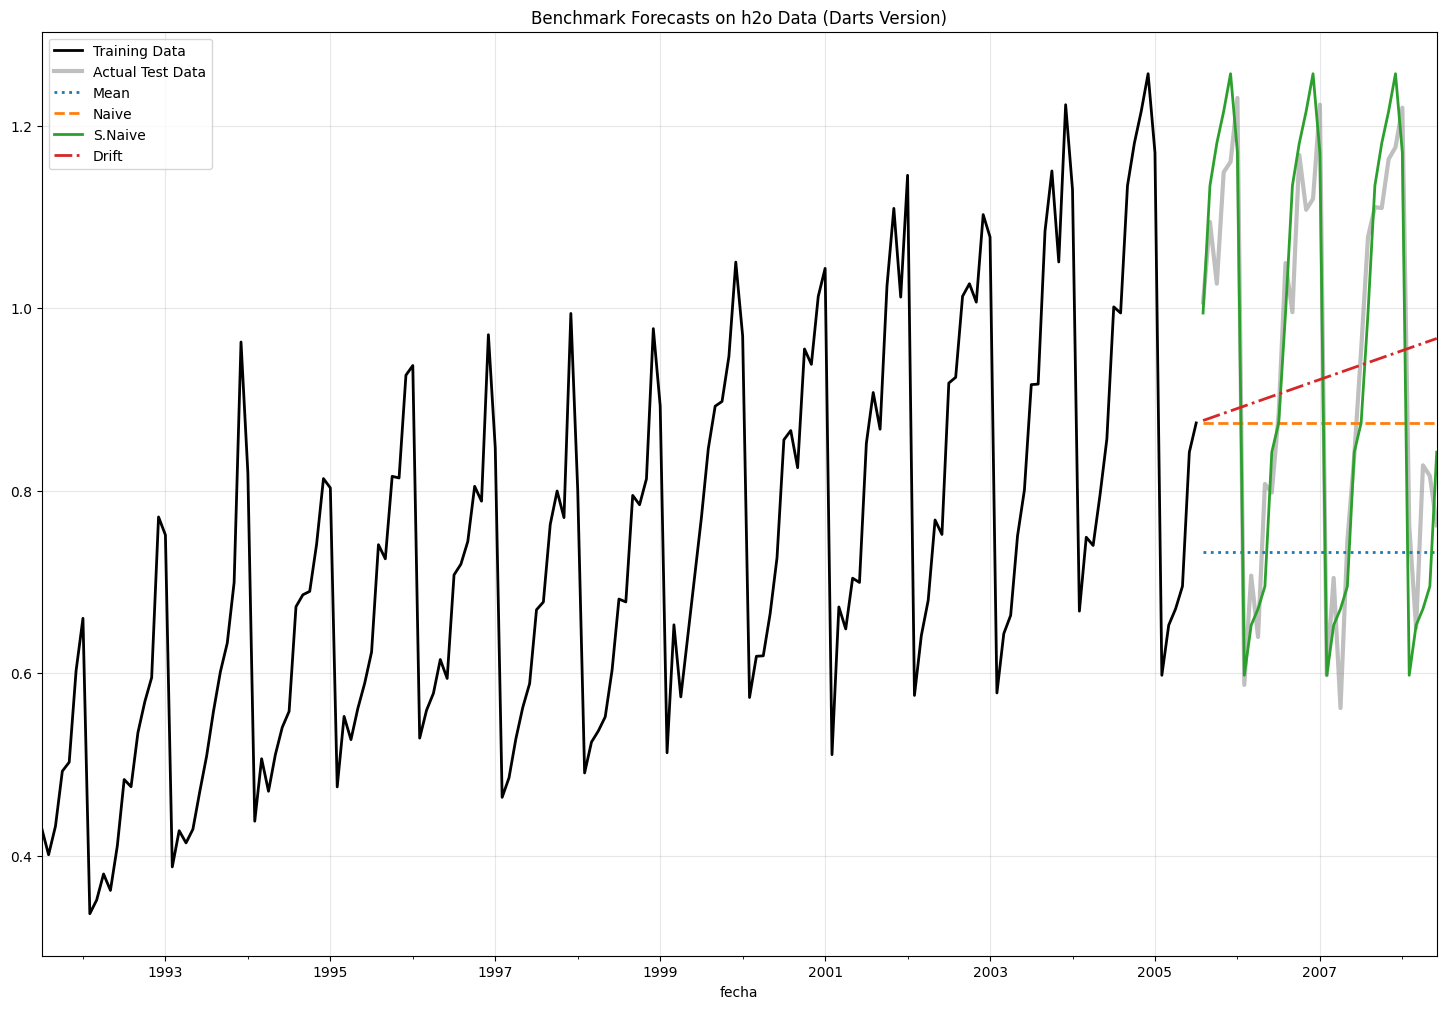

In [10]:
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NaiveMean, NaiveSeasonal, NaiveDrift

#Split Train/Test: first 14 year for training
train, test = y._split_at(14*12)

#Benchmark Models Definition
models = {
    "Mean": NaiveMean(),
    "Naive": NaiveSeasonal(K=1),      # K=1 means: use the immediately preceding value (Last Value)
    "S.Naive": NaiveSeasonal(K=12),   # K=12 means: repeat the seasonal cycle (last year's value)
    "Drift": NaiveDrift()             # Calculates the slope (drift) automatically
}

# Plot Setup
plt.figure(figsize=(18, 12))

# Plot actual data
train.plot(label='Training Data', color='black')
test.plot(label='Actual Test Data', color='gray', alpha=0.5, linewidth=3)

# Generate Forecasts & Plot Loop
styles = [':', '--', '-', '-.']
residuals = {}
# Iterate over the dictionary: fit, predict, and plot
for i, (name, model) in enumerate(models.items()):
    # a) Fit the model on training data
    model.fit(train)
    
    # b) Predict (horizon h = length of the test set)
    forecast = model.predict(len(test))
    
    # c) Calculate Residuals directly: (Actual - Forecast)
    # In Darts, you can subtract two TimeSeries objects directly
    res = test - forecast
    residuals[name] = res
    
    # c) Plot the forecast
    # Darts handles date indexing and alignment automatically
    forecast.plot(label=name, linestyle=styles[i])

plt.title("Benchmark Forecasts on h2o Data (Darts Version)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Residuals are useful in checking whether a model has adequately captured the information in the data. For this purpose, we use innovation residuals. If patterns are observable in the innovation residuals, the model can probably be improved.

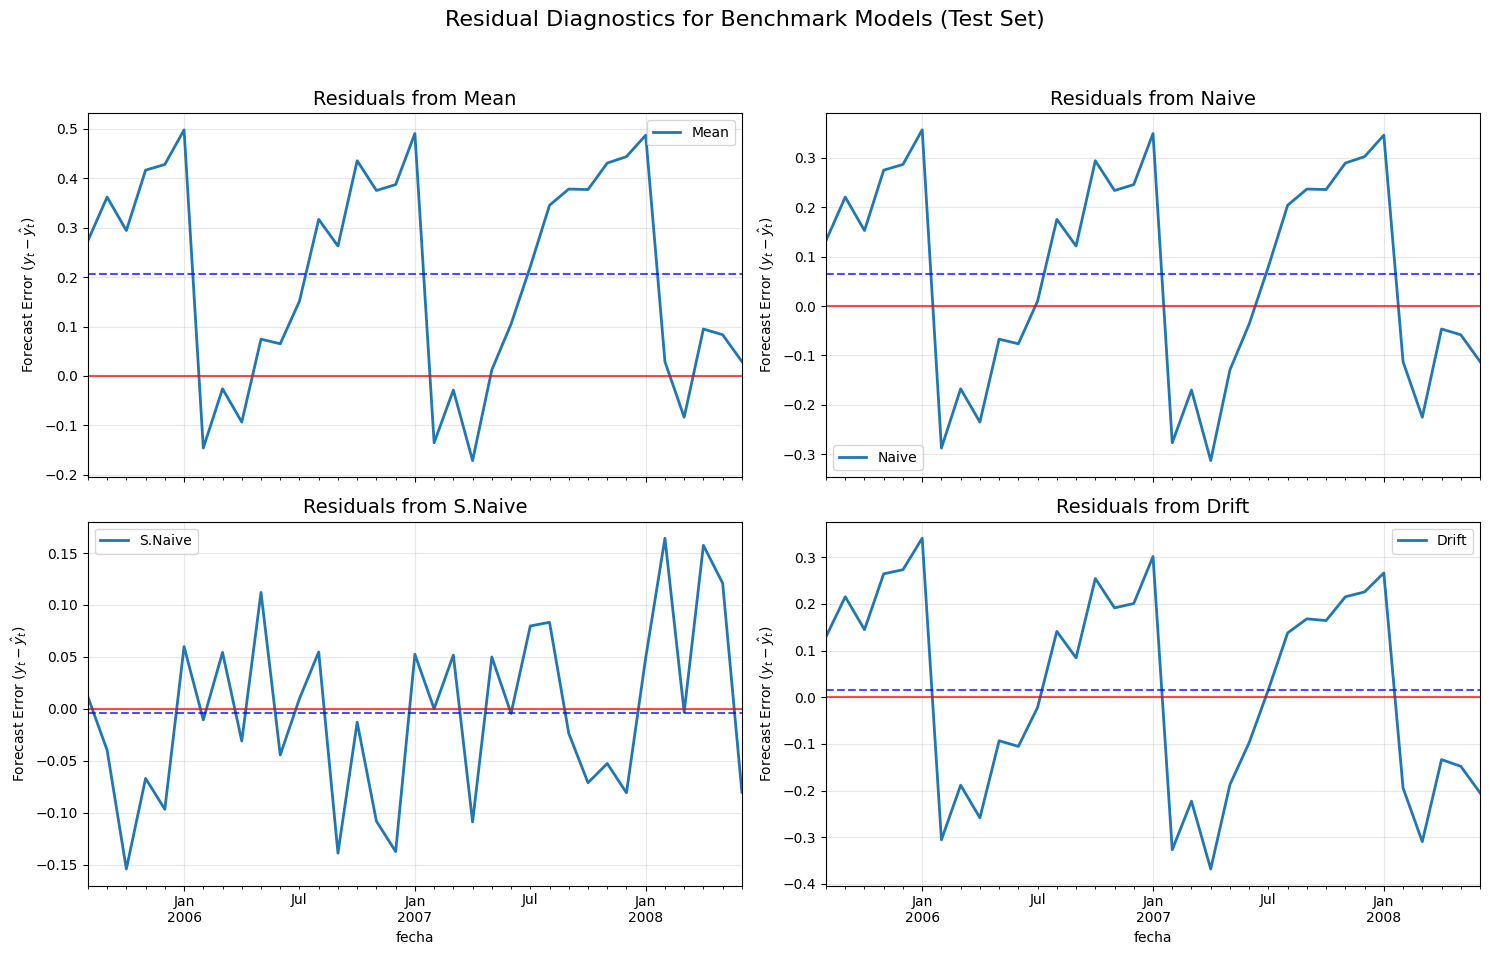

In [11]:
import numpy as np
# Plot Residuals for all four methods}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flattens the 2x2 array into a 1D array for easy iteration

# The column names in forecasts are the same as in residuals_df
for i, (name, residual) in enumerate(residuals.items()):
    # Plot residuals for the current method against the test index
    residual.plot(ax=axes[i], label=name)
    
    # Draw a line at y=0 (to check for bias)
    axes[i].axhline(0, color='red', linestyle='-', alpha=0.7)
    # Draw a line with residuals mean
    axes[i].axhline(residual.values().mean(), color='blue', linestyle='--', alpha=0.7)
    
    # Add titles and labels
    axes[i].set_title(f'Residuals from {name}', fontsize=14)
    axes[i].set_ylabel('Forecast Error ($y_t - \hat{y}_t$)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Residual Diagnostics for Benchmark Models (Test Set)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

A good forecasting method will yield residuals with specific properties:

1.  **Uncorrelated:** If correlations exist, there is information left in the residuals that should be used in computing forecast.

2.  **Zero Mean:** If the mean is not zero, the forecasts are biased.

    Useful properties (for distributions & prediction intervals)

3.  **Constant Variance:** Homoscedasticity

4.  **Normality distributed:** Useful for calculating prediction intervals

Residuals are often validated graficaly by using a time plot, the autocarrelation function (ACF) plot and a histogram of the residual.

C:\Users\ivons\AppData\Local\Temp\ipykernel_88108\2308528169.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

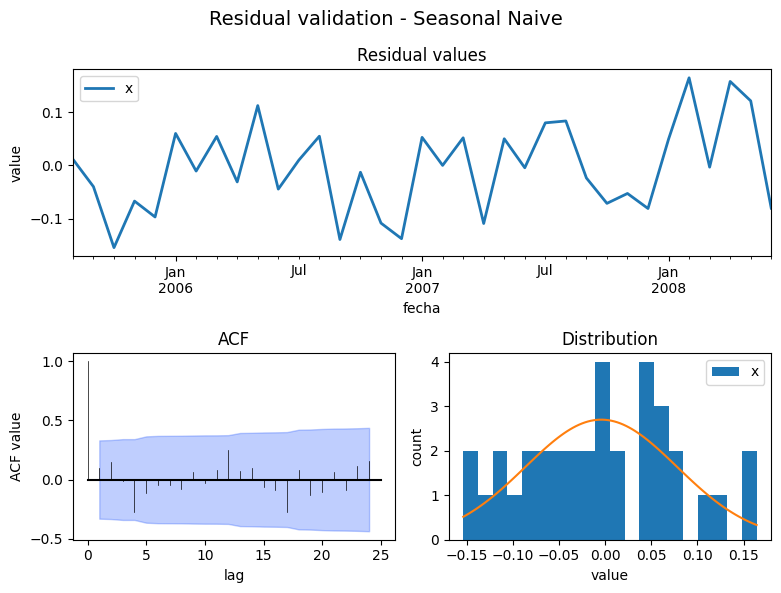

In [12]:
from darts.utils.statistics import plot_residuals_analysis

plt.figure(figsize=(10, 6))
plot_residuals_analysis(residuals['S.Naive'])
plt.suptitle("Residual validation - Seasonal Naive", fontsize=14)
plt.tight_layout()
plt.show()

-   The time plot of the residuals shows a mean close to zero and roughly constant variance across the historical data. Therefore the residuals' variance can be treated as constant (homoscedasticity assumption holds).

Normality assumption can be studied based on the histogram plot, but alternatively, Q-Q plots and a test of normality (shapiro-wikl test) can be used

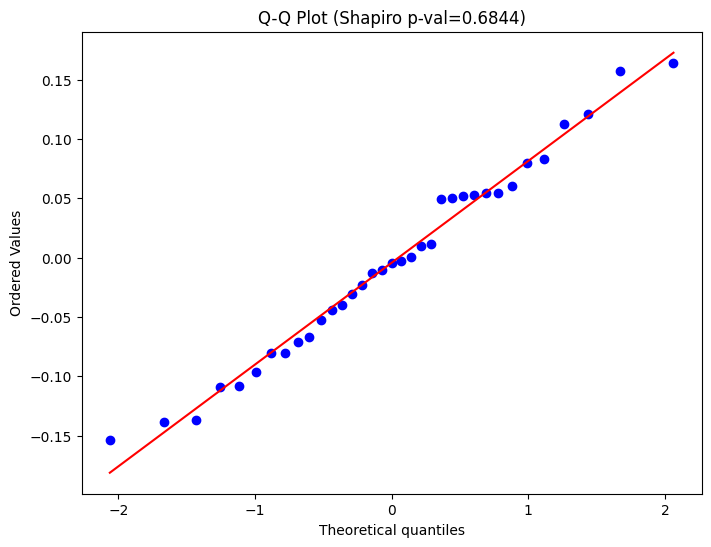

In [13]:
import matplotlib.pyplot as plt
import pylab
import scipy.stats as stats
from scipy.stats import shapiro

res = residuals['S.Naive'].values().flatten()
# Shapiro-Wilk Test
stat_shapiro, p_shapiro = shapiro(res)

plt.figure(figsize=(8, 6))
stats.probplot(res, dist="norm", plot=pylab)
plt.title(f"Q-Q Plot (Shapiro p-val={p_shapiro:.4f})")
plt.show()

-   Even though the histogram looks different from a normal distribution, the results from the Q-Q plot and Shapiro-Wilk test suggest that normality can be assumed for the residuals. This validates the use of prediction intervals, since it "guarantees" their theoretical framework.

-   The autocorrelation function plot shows no significant correlation in the residuals, indicating that the model has captured the information available in the data. However, sometimes, we have significant autocorrelation at some lag point. A formal tool to evaluate autocorrelation is a portmanteau test.

### 3.1. Portmanteau Tests

Instead of individually checking if lag 1 is zero, or if lag 2 is zero, the portmanteau test checks the joint hypothesis: "Are the first $l$ lags, as a whole, significantly different from zero?". If autocorrelation is not significantly different form zero (null hypothesis) means that residuals are independent (i.e. the residuals are white noise).

There are two versions: the Box-Pierce Test and the Ljung-Box Test. Both investigate the same hipothesys, but the Ljung-Box Test is a more powerful test and the recommended option, specially for small and medium-sized data samples.

To formally test for autocorrelation, the Ljung-Box Test uses the following test statistic:

$Q^{*} = T(T+2) \sum_{k=1}^{l} (T-k)^{-1} r_{k}^{2}$

where $r_k$ is the autocorrelation at lag $k$, $T$ is the size of the time series and $l$ the maximun lag being considered.

The test is not reliable when large values of $l$ are used. Usual recommendations include the using $l=10$ for non-seasonal data and $l=2m$ (where $m$ is the seasonal period) for seasonal data. Additionally, in this recommended $l$ values are larger than $T/5$, then $l=T/5$ is recommended instead.

Large values of $Q^{*}$ (low p-values) indicate the residuals are not white noise (significant autocorrelation exist).

In [14]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# res: residuals from Seasonal Naive model

# Ljung-Box Test (2*m for seasonal)
# NOTE that lags=[24] is a vector with one element, the value of l applied to the above 
# test statistic (Q*). If lags=24 is used then 24 tests are considered for l=1,...,24 
lb_test = acorr_ljungbox(res, lags=[24], return_df=True)
print("Ljung-Box Test p-value:", lb_test['lb_pvalue'].values[0].round(4))

Ljung-Box Test p-value: 0.3805


In this case, we observe a large p-value (0.3529); therefore, the null hypothesis is not rejected, and we cannot conclude that the residuals are correlated.

### 3.2. Exercise

Apply a seasonal naive method to the quarterly Australian beer production data. Use data from 1992 to 2005 for training and from 2006 for testing. Plot forecast and check the validity of the model (residuals). When checking if the residuals look like white noise, use both a graphical representation and the Portmanteau tests. What do you conclude about this model?

------------------------------------------------------------------------

## 4. Prediction Intervals

-   What we are trying to forecast is unknown, and so we can think of it as a random variable.

-   We can imagine many possible futures, each yielding a different value for the thing we wish to forecast.

![](Figures/posibleFutures.png)

-   When we obtain a forecast, we are estimating the middle of the range of possible values the random variable could take.

-   Often, a forecast is accompanied by a prediction interval giving a range of values the random variable could take with relatively high confidence measured in terms of probability.

-   Rather than plotting individual possible futures as shown in the previous Figure, we usually show these prediction intervals instead.

![](images/clipboard-2946094438.png)\](Figures/predictionInterval_forecasting.png)

-   The point forecast $\hat{y}_{T +h|T}$ is (usually) the mean of the conditional distribution $y_{T +h} | y_1 ,\ldots, y_T$ (forecast distribution).

### 4.1. Normal Residuals

Statistical time series models usually assume normally distributed residuals. If residuals are uncorrelated and normally distributed with standard deviation $\hat{\sigma}$:

| Method | Distribution |
|:---|:---|
| **Mean** | $y_{T+h \mid T} \sim N\left(\bar{y}, (1 + 1/T)\hat{\sigma}^2\right)$ |
| **Naïve** | $y_{T+h \mid T} \sim N\left(y_T, h\hat{\sigma}^2\right)$ |
| **Seasonal naïve** | $y_{T+h \mid T} \sim N\left(y_{T+h-m(k+1)}, (k+1)\hat{\sigma}^2\right)$ |
| **Drift** | $y_{T+h \mid T} \sim N \left( y_T + \frac{h}{T-1}(y_T - y_1), h \left(1 + \frac{h}{T-1} \right) \hat{\sigma}^2 \right)$ |

where $k$ is the integer part of $(h-1)/m$. Note that when $h=1$ and $T$ is large, these all give the same approximate forecast variance ($\hat{\sigma}^2$)

A prediction interval gives a region within which we expect $y_{T +h}$ to lie with a specified confidence measured in terms of probability.

Under normally assumption for the residuals, a 95% PI is:

$$\hat{y}_{T+h|T} \pm 1.96 \hat{\sigma}_h$$

where $\hat{\sigma}^2$ is the standard deviation of the $h$-step distribution.

The `Darts` module does not implement this formula to obtain prediction intervals. Instead, it implements a sample-based framework (Monte Carlo sampling) via the `TimeSeries` object. This allows it to represent any distribution—whether it is a parametric Normal distribution, a generic distribution learned by a neural network, or a bootstrapped distribution based on historical residuals. However, only includes functions to compute prediction intervals for probabilistic models and the models shown in this chapter are deterministic. Fortunately, the `sktime` library includes includes a straightforward way to perform this calculation.

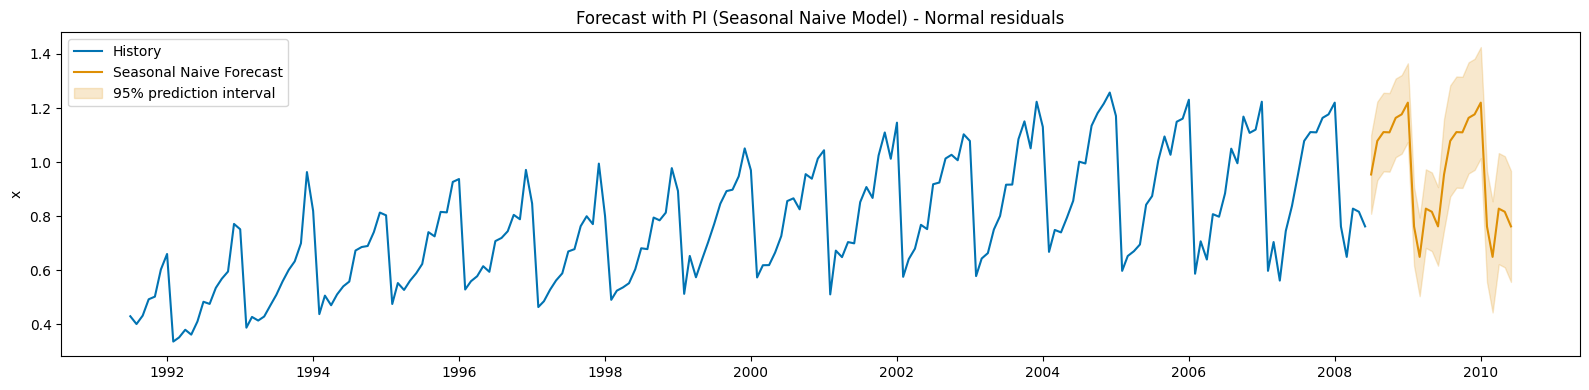

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

# sktime specific imports
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# Forecasting using Seasonal Naive (sktime implementation)
m = 12 
model = NaiveForecaster(strategy="last", sp=m)
# Fit the model to the historical series
model.fit(y_skt)
# Define the forecast horizon (h)
h = 24 
# ForecastingHorizon creates the sequence [1, 2, ..., 24] relative to the last training point
fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True)
# Generate predictions
forecast = model.predict(fh)

# Generate prediction intervals
interval = model.predict_interval(fh, coverage=0.95)
interval.head()

# Plot using plot_series
fig, ax = plot_series(
    y_skt,                      # Historical data
    forecast,               # Point prediction
    labels=["History", "Seasonal Naive Forecast"], 
    markers=[None,None], 
    pred_interval=interval  # prediction interval
)

plt.title("Forecast with PI (Seasonal Naive Model) - Normal residuals")
plt.tight_layout()
plt.show()

### 4.2. Bootstrapped Residuals

If the normal distribution assumption is unreasonable, we simulate future paths using randomly sampled errors from the past. That is, instead of using a normal distribution for the errors (residuals), the empirical distribution of the errors is used:

$$
y_{T+1}^{*} = \hat{y}_{T+h} + e_{T+h}^{*}
$$

where $\hat{y}_{T+h}$ is the model prediction at time $t+h$ and $e^{*}$ is a random draw from the residuals.

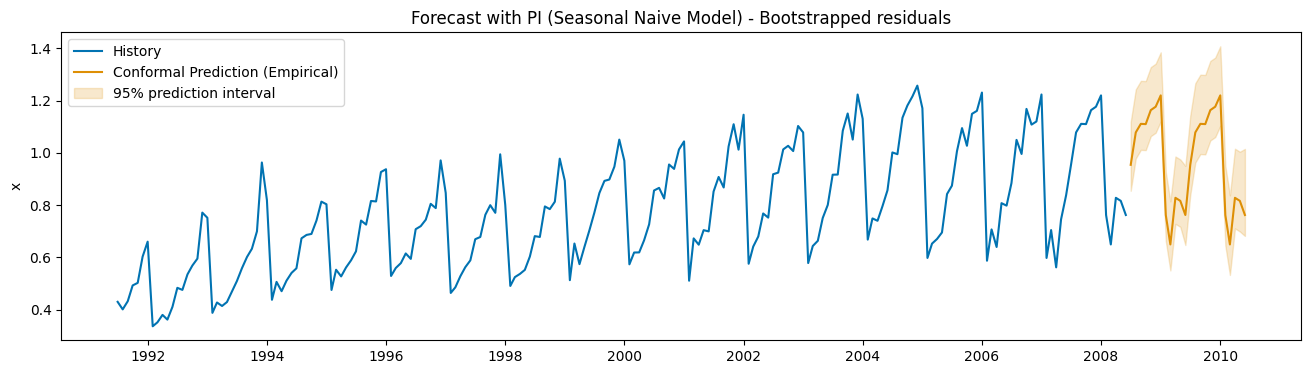

In [16]:
from sktime.forecasting.conformal import ConformalIntervals

# Forecasting using Seasonal Naive (sktime implementation)
model = NaiveForecaster(strategy="last", sp=12)

# WRAP the model to generate "Empirical/Conformal" intervals
# method="empirical": Uses residuals from a sliding window to calculate the interval
# (This avoids the assumption that errors follow a normal distribution)
model_conformal = ConformalIntervals(model, method="empirical")

# Fit and Predict (Using the wrapped model)
model_conformal.fit(y_skt)
forecast = model_conformal.predict(fh)
quantiles = model_conformal.predict_interval(fh, coverage=0.95) # lower-upper bound for the prediction interval

# Plot
plot_series(
    y_skt, 
    forecast, 
    labels=["History", "Conformal Prediction (Empirical)"],
    pred_interval=quantiles,
    markers=[None, None]
)
plt.title("Forecast with PI (Seasonal Naive Model) - Bootstrapped residuals")
plt.show()

`Darts` uses a simulation methodology similar to the one described above. If the prediction model assumes that residuals follow a normal distribution, the future paths are obtained by simulating a normal distribution. By contrast, if the prediction model does not assume normality for residuals, the empirical distribution is used being this process transparent to the user. Nevertheless, under normality assumption, even though this method obtains almost the same results as the method introduced in 4.1, the method from 4.1 is much faster.

As an example we also include the code to obtain prediction intervals with `darts` for a probabilistic model such as ARIMA. This model assumes normality on residuals and will be studied in the next chapter.

c:\Users\ivons\OneDrive\Documentos\taimin\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


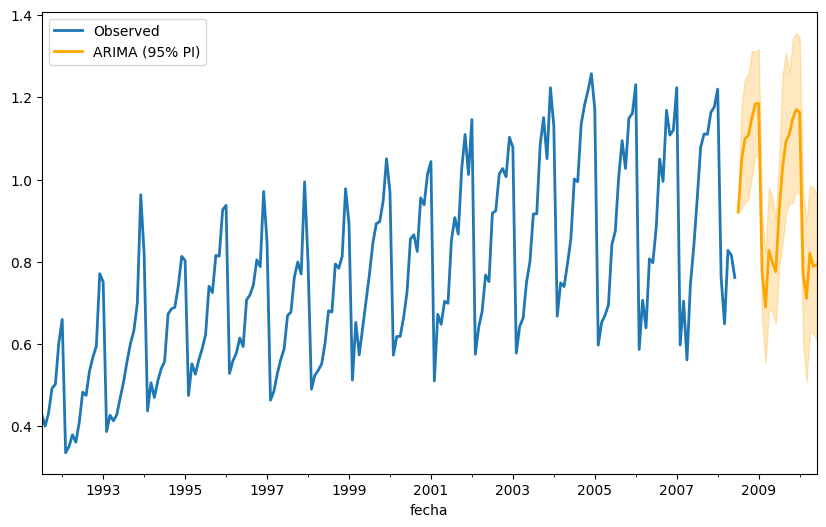

In [17]:
from darts.models import ARIMA

# ARIMA(12, 1, 0)
model = ARIMA(p=12, d=1, q=0)
model.fit(y)
# num_samples=200: Darts obtains 200 future paths to obtain the forecast (mean) and prediction interval
h=24
pred = model.predict(24, num_samples=200) 
pred.head()

# Plot
plt.figure(figsize=(10, 6))
y.plot(label="Observed")

# plot the shadowed are between quantiles and the median value as a solid line
pred.plot(
    low_quantile=0.025,  # lower limit (2.5%)
    high_quantile=0.975, # upper limit (97.5%) -> 95% PI
    label="ARIMA (95% PI)", 
    color="orange"
)

plt.legend()
plt.show()

------------------------------------------------------------------------

## 5. Metrics to Evaluate Forecasting Performance

Once a model has been fitted and diagnosed, the next step is to evaluate its predictive power on unseen data. While diagnostic checks (like residual analysis) ensure the model's assumptions hold true, accuracy metrics quantify how close the forecasts are to the actual observed values.

In this section, we study the most common metrics used to measure forecast accuracy. These are typically calculated on a test set (out-of-sample evaluation).

### 5.1. Scale-Dependent Metrics

These metrics calculate the error in the same units as the original data (e.g., if the data is in euros, the error is in euros). They are useful for comparing different models on the same specific dataset, but they cannot be used to compare performance across different time series with different scales.

-   **MAE (Mean Absolute Error)**: It measures the average magnitude of the errors in a set of predictions, without considering their direction. It is easy to interpret.

    $$
    MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|
    $$

-   **RMSE (Root Mean Squared Error)**: It is the square root of the average of squared differences between prediction and actual observation.

    $$
    RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}
    $$

    Since the errors are squared before they are averaged, the RMSE gives a relatively high weight to large errors. This means the RMSE should be more useful when large errors are particularly undesirable.

### 5.2. Percentage Metrics

These metrics are unit-free, meaning they express the error as a percentage. This makes them ideal for comparing forecast performance across datasets with different scales. However, they become undefined or unstable if the actual values ($y_t$) are zero or close to zero.

-   **MAPE (Mean Absolute Percentage Error)**: This is one of the most common measure of forecast accuracy in business.

    $$
    MAPE = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t-\hat{y}_t}{y_t}\right|
    $$

    Note that MAPE is measured in percentage (0-100 scale) and it is equivalent to the Mean Absolute Relative Error (MARE) which by avoiding the 100 multiplier is measured on a 0-1 scale.

    A limitation of this metric is that it is undefined if $y_t = 0$. Furthermore, assuming strictly positive data ($y_t > 0$), it puts a heavier penalty on forecasts that exceed the actual values (over-forecasting) compared to under-forecasting, because the denominator ($y_t$) becomes smaller in those cases. By contrast, this tendency reverses with negative values. Consequently, its use is generally avoided when negative values can occur in the time series data.

-   **sMAPE (Symmetric Mean Absolute Percentage Error):** This metric was proposed to address the asymmetry and instability issues of MAPE. Instead of dividing only by the actual value ($y_t$), it divides by the average of the absolute actual and predicted values.

    $$
    SMAPE = \frac{100}{n}\sum_{t=1}^{n}\frac{|y_t-\hat{y}_t|}{(|y_t|+|\hat{y}_t|)/2}
    $$

    *This* metric is bounded between 0% and 200%, and it does not explode to infinity if $y_t = 0$ (unless both $y_t$ and $\hat{y}_t$ are zero). It is symmetric in the sense that swapping $y_t$ and $\hat{y}_t$ yields the same error value. However, the interpretation can be counter-intuitive because a perfect error is 0%, but the maximum possible error is 200%. Furthermore, this metric fails to distinguish between a small deviation and a massive error in those cases where one of the values $y_t$ or $\hat{y}_t$ is 0. In such scenarios, the metric saturates at the maximum penalty regardless of the actual magnitude of the error.

    Some implementations omit the division by 2 (comparing the error to the sum instead of the average). In that case, the metric is bounded between 0% and 100%. It is important to always verify which definition is being used by the software library.

### 5.3. Scaled Metrics

Scaled errors are considered the most robust method for comparing forecast accuracy across different time series with varying scales (e.g., comparing the forecast error of "Bread Sales" in units vs. "Revenue" in millions of euros). Unlike percentage metrics, they do not rely on dividing by the exact value $y_t$, thus avoiding the issues associated with zero values.

The main idea behind scaled metris is to scale the error based on the in-sample Mean Absolute Error of a simple benchmark model (typically the Naive or Seasonal Naive method).

-   **MASE (Mean Absolute Scaled Error):** Proposed by Hyndman and Koehler (2006), it compares the MAE of the proposed model against the MAE of the naive benchmark.

    $$
    MASE = \frac{MAE}{MAE_{naive}}
    $$

    Where:

    -   $MAE$ is the Mean Absolute Error of the evaluated model on the test set.

    -   $MAE_{naive}$ is the Mean Absolute Error of the (*Seasonal) Naive* forecast calculated on the training set. Ideally, this acts as a scaling factor that represents the "natural variability" of the series.

    MASE has a very intuitive interpretation relative to the benchmark:

    -   **MASE \< 1:** The proposed model yields smaller errors than the Naïve benchmark. This indicates the model provides real predictive value.

    -   **MASE \> 1:** The proposed model performs worse than the Naïve benchmark. This suggests the model is not useful, as a simple random walk would perform better.

    -   **MASE = 1:** The model performs exactly as well as the Naïve method.

    This metric is applicable to almost any time series (including those with zero or negative values) and allows for averaging across different time series.

In [18]:
import pandas as pd
from skforecast.datasets import fetch_dataset
from darts import TimeSeries
from darts.models import NaiveSeasonal
from darts.metrics import mae, rmse, mape, smape, mase

# 1. Load and prepare data (Darts format)
data = fetch_dataset(name='h2o', raw=True)
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
y = TimeSeries.from_dataframe(data, time_col='fecha', value_cols='x', freq='MS')

# 2. Split data into Train and Test sets
# We use the last 24 months for testing (validation)
train, test = y.split_before(len(y) - 24)

# 3. Generate a Forecast
# We use Seasonal Naive as our model
model = NaiveSeasonal(K=12)
model.fit(train)
forecast = model.predict(len(test))

# 4. Calculate Accuracy Metrics
# Note: Compare the 'test' (actual) vs 'forecast' (predicted)

# Scale-Dependent
mae_score = mae(test, forecast)
rmse_score = rmse(test, forecast)

# Percentage (Darts returns 0-100 scale by default)
mape_score = mape(test, forecast)
smape_score = smape(test, forecast)

# Scaled
# MASE needs the training data (insample) to calculate the benchmark error
mase_score = mase(test, forecast, insample=train)

# 5. Display Results
results_darts = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae_score, rmse_score, mape_score, smape_score, mase_score]
})

print(results_darts.round(3))

╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 2 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

      Metric  Value
0        MAE  0.056
1       RMSE  0.075
2   MAPE (%)  6.336
3  sMAPE (%)  6.564
4       MASE  0.590


To compute the same metrics with `sktime`\` we can use the following code:

In [19]:
import pandas as pd
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_scaled_error
)

# 2. Split data into Train and Test sets
# We use the last 24 months for testing
y_train, y_test = temporal_train_test_split(y_skt, test_size=24)

# 3. Generate a Forecast
# NaiveForecaster with strategy="last" and sp=12 is equivalent to Seasonal Naive
forecaster = NaiveForecaster(strategy="last", sp=12)
forecaster.fit(y_train)
# Predict the next 24 periods (matching the test set length)
fh = list(range(1, 25)) 
y_pred = forecaster.predict(fh)

# 4. Calculate Accuracy Metrics

# Scale-Dependent
mae_score = mean_absolute_error(y_test, y_pred)
# sktime uses mean_squared_error with square_root=True for RMSE
rmse_score = mean_squared_error(y_test, y_pred, square_root=True)

# Percentage
# Note: sktime returns ratios (0-1 scale) or 0-2 scale for sMAPE. 
# We multiply by 100 to get percentages (0-100% or 0-200%)
mape_score = mean_absolute_percentage_error(y_test, y_pred, symmetric=False) * 100
smape_score = mean_absolute_percentage_error(y_test, y_pred, symmetric=True) * 100

# Scaled (MASE)
# CRITICAL: 
# 1. We must pass y_train to calculate the benchmark scaling.
mase_score = mean_absolute_scaled_error(y_test, y_pred, y_train=y_train)

# 5. Display Results
results_sktime = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae_score, rmse_score, mape_score, smape_score, mase_score]
})

print(results_sktime.round(3))

      Metric  Value
0        MAE  0.056
1       RMSE  0.075
2   MAPE (%)  6.336
3  sMAPE (%)  6.564
4       MASE  0.590


***Important Implementation Detail:*** When calculating MASE for seasonal data using darts (or sktime), the seasonality period $m$ for the benchmark is not automatically inferred. It defaults to $m=1$ (standard Naive benchmark). To use the correct Seasonal Naive benchmark as defined by Hyndman, you must explicitly pass the seasonality parameter (e.g., `m=12` in `darts` or `sp=12` in `sktime` for monthly data) to the metric function.

### 5.4. Exercise

Compute the MASE metric for the seasonal naive model using also a seasonal naive as a benchmark model with both `darts` and `sktime` libraries. What values do you expect to obtain in this case? What are the values you finally obtain? How do you interpret the obtained values?

------------------------------------------------------------------------


In [20]:
# Exercise 5.4 Solution:
# MASE for Seasonal Naive model using Seasonal Naive as benchmark

# Expected Result: MASE = 1.0
# Reason: We're comparing the model against itself (Seasonal Naive vs Seasonal Naive)
# This means the forecast error will be exactly equal to the benchmark error.

print("=" * 60)
print("Exercise 5.4: MASE with Seasonal Naive Benchmark")
print("=" * 60)

# ==========================================
# DARTS Implementation
# ==========================================
print("\n--- DARTS Implementation ---")

# The key parameter is m=12 (seasonality period)
# m=1 (default) would use standard Naive as benchmark
# m=12 uses Seasonal Naive as benchmark

from darts.metrics import mase

# Using the same train/test split from the previous example
mase_darts_seasonal = mase(test, forecast, insample=train, m=12)

print(f"MASE (Seasonal Naive model vs Seasonal Naive benchmark): {mase_darts_seasonal:.4f}")

# ==========================================
# SKTIME Implementation
# ==========================================
print("\n--- SKTIME Implementation ---")

# The key parameter is sp=12 (seasonality period)
# sp=1 (default) would use standard Naive as benchmark
# sp=12 uses Seasonal Naive as benchmark

from sktime.performance_metrics.forecasting import mean_absolute_scaled_error

# Using the same train/test split from the previous example
mase_sktime_seasonal = mean_absolute_scaled_error(y_test, y_pred, y_train=y_train, sp=12)

print(f"MASE (Seasonal Naive model vs Seasonal Naive benchmark): {mase_sktime_seasonal:.4f}")

# ==========================================
# Interpretation
# ==========================================
print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)
print(f"""
Expected Value: MASE ≈ 1.0

Actual Values:
  - Darts:  {mase_darts_seasonal:.4f}
  - Sktime: {mase_sktime_seasonal:.4f}

Why MASE = 1.0?
  When we use Seasonal Naive as both the forecasting model AND the 
  benchmark model, we are essentially comparing the model to itself.
  
  MASE = MAE(model) / MAE(benchmark)
  
  Since the model IS the benchmark:
  MASE = MAE(Seasonal Naive) / MAE(Seasonal Naive) = 1.0
  
Conclusion:
  This confirms that MASE is correctly implemented. A value of 1.0 
  means the model performs exactly as well as the benchmark.
  
  In practice, you would use a DIFFERENT benchmark (like Naive with m=1)
  to evaluate whether your Seasonal Naive model provides value.
  If MASE < 1.0, your model beats the benchmark.
  If MASE > 1.0, your model is worse than the benchmark.
""")

Exercise 5.4: MASE with Seasonal Naive Benchmark

--- DARTS Implementation ---
MASE (Seasonal Naive model vs Seasonal Naive benchmark): 0.9287

--- SKTIME Implementation ---
MASE (Seasonal Naive model vs Seasonal Naive benchmark): 0.9287

INTERPRETATION:

Expected Value: MASE ≈ 1.0

Actual Values:
  - Darts:  0.9287
  - Sktime: 0.9287

Why MASE = 1.0?
  When we use Seasonal Naive as both the forecasting model AND the 
  benchmark model, we are essentially comparing the model to itself.

  MASE = MAE(model) / MAE(benchmark)

  Since the model IS the benchmark:
  MASE = MAE(Seasonal Naive) / MAE(Seasonal Naive) = 1.0

Conclusion:
  This confirms that MASE is correctly implemented. A value of 1.0 
  means the model performs exactly as well as the benchmark.

  In practice, you would use a DIFFERENT benchmark (like Naive with m=1)
  to evaluate whether your Seasonal Naive model provides value.
  If MASE < 1.0, your model beats the benchmark.
  If MASE > 1.0, your model is worse than the be


## 6. Validation Strategies

Validating a time series model requires a fundamental shift in mindset compared to standard machine learning. In traditional regression or classification (e.g., classifying images), observations are assumed to be independent (i.i.d.), allowing for random splitting of data.

**In Time Series, order matters.** Observations are correlated with time. Therefore, we must adhere to the Golden Rule of Backtesting:Never use future information to predict the past

> "A forecast is a prediction of the future based on information available at the time the forecast is made." (Hyndman & Athanasopoulos, 2021)

Therefore, standard randomized K-Fold Cross-Validation is strictly forbidden here, as it breaks the temporal structure and causes "look-ahead bias" (the model peeks into the future).

### 6.1. Train/Test Split (Fixed Split)

This is the simplest approach, analogous to the "hold-out" method in general machine learning, but respecting the chronological order.

The dataset is split into two segments at a specific cutoff point in time:

-   **Training Set:** The first part of the dataset used to fit the model parameters. Usually $80\%$ (or $70\%$) of the data is taken for training.

-   **Test Set:** The final part of the dataset (usually the remaining $20\%$ or $30\%$) is reserved for performance evaluation.

    ![](Figures/validation_TrainTest.png)

This validation strategy is computationally fast, as the model is trained only once, making it useful for initial prototyping. However, a significant drawback is that the performance estimate depends heavily on the specific period selected for testing. If the test set falls on a particularly volatile period (e.g., the COVID-19 pandemic) or a very stable one, the results may be misleading.

### 6.2. Walk-Forward Validation (Time Series Cross-Validation)

Also known as **Backtesting**, this is the gold standard for time series validation. It provides a more robust estimate of error by averaging the model's performance over multiple test sets across time.

Instead of a single split, we create multiple "folds" sliding through time. In each fold:

1.  We train the model up to time $t$.

2.  We forecast $h$ steps ahead (the horizon).

3.  We calculate the error.

4.  We advance the time origin and repeat.

The specific split of the dataset into training and testing sets is determined by the window type used within the walk-forward strategy. There are two main strategies for defining the training set size as we move forward.

#### 6.2.1. Expanding Window

With each successive fold, the size of the training set increases. The training set's starting point remains fixed, while its endpoint is incrementally advanced. This validation methodology is appropriate when the principle that "more data yields better results" holds true and the underlying process is stable. The model consequently benefits from learning the entire historical sequence.

![](Figures/validation_ExpandingWindow.png)

#### 6.2.2. Rolling Window (Sliding Window)

The training set maintains a fixed size. As the process advances, the oldest observations are systematically discarded. Consequently, both the starting and ending points of the training set move forward simultaneously. This validation methodology is particularly appropriate when the underlying process is susceptible to regime changes or structural breaks. In such cases, historical data may be obsolete or misleading (e.g., consumer behavior from a decade ago may no longer be relevant).

![](Figures/validation_RollingWindow.png)

### 6.3. Common Pitfalls

1.  Look-Ahead Bias (Data Leakage):

    This occurs when information from the test set leaks into the training process.

    -   *Example:* Calculating the mean or standard deviation for normalization using the entire dataset before splitting. You must calculate scaling statistics *only* on the training set and apply them to the test set.

2.  Random Shuffling:

    Using train_test_split(shuffle=True) from scikit-learn. This destroys the autocorrelation structure and allows the model to predict Monday using data from Tuesday, which is impossible in real life.

3.  Insufficient Test Set Size:

    If the test set is too small (e.g., predicting only 2 points), metrics like MAPE becomes highly volatile and statistically insignificant. The test horizon should match the business objective (e.g., if you need to plan inventory for 3 months, your test folds should be 3 months long).

4.  Ignoring Gap (Embargo):

    In some real-world scenarios, data is not available immediately. If there is a delay in data acquisition, you might need to introduce a "Gap" between the Training and Test sets to simulate realistic deployment conditions.

### 6.4. Using Python

Both the `darts` and `sktime` packages implement these validation strategies. In the following examples, we will demonstrate how to utilize these implementations to evaluate a seasonal naive model on the H2O dataset, employing the Root Mean Square Error (RMSE) and Mean Absolute Percentage Error (MAPE) metrics, along with the validation strategies introduced in this section.

#### 6.4.1. Darts Implementation

In [21]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import NaiveSeasonal
from darts.metrics import rmse, mape

# --- Assuming 'y' is your Darts TimeSeries object ---
# y = TimeSeries.from_dataframe(data, time_col='fecha', value_cols='x', freq='MS')

# Define the model (Seasonal Naive, annual cycle K=12)
model_darts = NaiveSeasonal(K=12)

# ==========================================
# STRATEGY 1: Train-Test (Simple Partition)
# ==========================================
# Split: 80% training, 20% validation
train, val = y.split_before(0.80)

# Fit and predict
model_darts.fit(train)
pred_val = model_darts.predict(len(val))

# Calculate metrics
print("--- Darts: Hold-out ---")
print(f"RMSE: {rmse(val, pred_val):.2f}")
print(f"MAPE: {mape(val, pred_val):.2f}%")

# ==========================================
# STRATEGY 2: Walk-Forward
# ==========================================
# Darts simplifies this with the .backtest() function.
# start=0.5: Start validation when 50% of the data is available.
# forecast_horizon=12: Predict 12 months ahead at each step.
# stride=1: Move the window 1 month at a time.
# retrain=False: If False, the model is trained only once (with the first 50% of the data) and then used to predict given the test set. If True, the model is trained on each trainset before predicting new values. NaiveSeasonal is not needed to retrain since it has no parameters to estimate.

# Expanding Window
print("\n--- Darts: Walk-Forward (Expanding Window) ---")

# Calculate average RMSE over all windows
cv_rmse_expanding = model_darts.backtest(
    y,
    start=0.5,           # Temporal starting point
    forecast_horizon=12, # Forecast horizon
    metric=rmse,         # Metric to evaluate
    reduction=np.mean    # How to aggregate errors (mean)
)

# Calculate average MAPE over all windows
cv_mape_expanding = model_darts.backtest(
    y,
    start=0.5,
    forecast_horizon=12,
    metric=mape,
    reduction=np.mean
)

print(f"CV RMSE (Average) - Expanding Window: {cv_rmse_expanding:.2f}")
print(f"CV MAPE (Average) - Expanding Window: {cv_mape_expanding:.2f}%")

# Sliding Window
print("\n--- Darts: Walk-Forward (Sliding Window) ---")

# Calculate average RMSE over all windows
cv_rmse_sliding = model_darts.backtest(
    y,
    start=0.5,           # When to start validation (temporal starting point)
    forecast_horizon=12, # Forecast horizon
    stride=1,            # How often to move the window (step size)
    metric=rmse,         # Metric to evaluate
    reduction=np.mean,   # How to aggregate errors (mean)
    
    # --- KEY CHANGES FOR SLIDING WINDOW ---
    retrain=True,        # Re-train the model at each step, not neede for seasonal naive
    train_length=24      # Use a fixed window of 24 months for training (sliding window)
)


# Calculate average RMSE over all windows
cv_mape_sliding = model_darts.backtest(
    y,
    start=0.5,           # When to start validation (temporal starting point)
    forecast_horizon=12, # Forecast horizon
    stride=1,            # How often to move the window (step size)
    metric=mape,         # Metric to evaluate
    reduction=np.mean,   # How to aggregate errors (mean)
    
    # --- KEY CHANGES FOR SLIDING WINDOW ---
    retrain=True,        # Re-train the model at each step, not neede for seasonal naive
    train_length=24      # Use a fixed window of 24 months for training (sliding window)
)

print(f"Sliding Window RMSE: {cv_rmse_sliding:.2f}")
print(f"Sliding Window RMSE: {cv_mape_sliding:.2f}%")

--- Darts: Hold-out ---
RMSE: 0.08
MAPE: 8.87%

--- Darts: Walk-Forward (Expanding Window) ---
CV RMSE (Average) - Expanding Window: 0.07
CV MAPE (Average) - Expanding Window: 6.54%

--- Darts: Walk-Forward (Sliding Window) ---
Sliding Window RMSE: 0.07
Sliding Window RMSE: 6.54%


#### 6.4.2. sktime Implementation

In [22]:
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.model_selection import (
    temporal_train_test_split,
    ExpandingWindowSplitter,
    SlidingWindowSplitter
)
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsolutePercentageError

# --- Load and Format Data (h2o dataset) ---
#data = fetch_dataset(name='h2o', raw=True)
#data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
#data = data.set_index('fecha')

# Convert to Period Index (Monthly) required for proper sktime functioning
#y_skt = data['x'].to_period('M')

# Define the model (Seasonal Naive, annual cycle sp=12)
model_skt = NaiveForecaster(strategy="last", sp=12)

# Define Metrics
# square_root=True to get RMSE
rmse_metric = MeanSquaredError(square_root=True) 
# symmetric=False to get standard MAPE
mape_metric = MeanAbsolutePercentageError(symmetric=False) 

# ==========================================
# STRATEGY 1: Train-Test (Simple Partition)
# ==========================================
# Split: 80% training, 20% validation
y_train, y_test = temporal_train_test_split(y_skt, train_size=0.80)

# Fit and predict
model_skt.fit(y_train)

# Define forecast horizon (fh) based on test set length
fh = np.arange(len(y_test)) + 1
y_pred = model_skt.predict(fh)

# Calculate metrics
print("--- Sktime: Train-Test ---")
print(f"RMSE: {rmse_metric(y_test, y_pred):.2f}")
print(f"MAPE: {mape_metric(y_test, y_pred)*100:.2f}%")

# ==========================================
# STRATEGY 2: Walk-Forward (Expanding Window)
# ==========================================
# We replicate 'start=0.5' by setting initial_window to 50% of total length.
# forecast_horizon=12: Predict 12 months ahead (fh=[1, 2, ..., 12])
# step_length=1: Move the window 1 month at a time.

print("\n--- Sktime: Walk-Forward (Expanding Window) ---")

initial_window_size = int(len(y_skt) * 0.5)

cv_expanding = ExpandingWindowSplitter(
    initial_window=initial_window_size,
    step_length=1,
    fh=np.arange(1, 13) # Forecast Horizon 1 to 12
)

# Evaluate (Calculates both metrics at once)
results_expanding = evaluate(
    forecaster=model_skt,
    cv=cv_expanding,
    y=y_skt,
    scoring=[rmse_metric, mape_metric]
)

# Calculate average metrics
mean_rmse_exp = results_expanding['test_MeanSquaredError'].mean()
mean_mape_exp = results_expanding['test_MeanAbsolutePercentageError'].mean()

print(f"CV RMSE (Average) - Expanding Window: {mean_rmse_exp:.2f}")
print(f"CV MAPE (Average) - Expanding Window: {mean_mape_exp*100:.2f}%")

# ==========================================
# STRATEGY 3: Walk-Forward (Sliding Window)
# ==========================================
# window_length=24: Equivalent to 'train_length=24' in Darts.
# Sktime automatically handles the "retrain" logic because it fits a new model 
# instance for every fold in the cross-validation.

print("\n--- Sktime: Walk-Forward (Sliding Window) ---")

cv_sliding = SlidingWindowSplitter(
    window_length=24,   # Fixed window size (training data)
    step_length=1,      # Step size
    fh=np.arange(1, 13) # Forecast Horizon
)

# Evaluate
results_sliding = evaluate(
    forecaster=model_skt,
    cv=cv_sliding,
    y=y_skt,
    scoring=[rmse_metric, mape_metric]
)

# Calculate average metrics
mean_rmse_slide = results_sliding['test_MeanSquaredError'].mean()
mean_mape_slide = results_sliding['test_MeanAbsolutePercentageError'].mean()

print(f"Sliding Window RMSE: {mean_rmse_slide:.2f}")
print(f"Sliding Window MAPE: {mean_mape_slide*100:.2f}%")

--- Sktime: Train-Test ---
RMSE: 0.08
MAPE: 8.76%

--- Sktime: Walk-Forward (Expanding Window) ---
CV RMSE (Average) - Expanding Window: 0.07
CV MAPE (Average) - Expanding Window: 6.55%

--- Sktime: Walk-Forward (Sliding Window) ---
Sliding Window RMSE: 0.07
Sliding Window MAPE: 7.29%


### 6.5. Exercise

**Context**

You are working as a Data Scientist for an airline company. The management needs a reliable forecast for passenger traffic to plan flight schedules for the next year. You have access to the classic Air Passengers dataset (monthly data from 1949 to 1960).

In [23]:
from darts.datasets import AirPassengersDataset
from sktime.datasets import load_airline

#if you want to use darts (TimeSeries object)
y = AirPassengersDataset().load()
#if you want to use sktime (pandas' Series object)
y = load_airline()

Before trying complex algorithms (like ARIMA or Transformers), your boss wants you to establish a robust baseline. You need to compare simple strategies to understand the nature of the data.

**The Models & The Hypothesis**

We will compare three fundamental approaches. The core of this exercise is to test the following hypothesis regarding Trend vs. Seasonality:

1.  **Seasonal Naive:** This model assumes that "what happened last January will happen this January."

    -   *Hypothesis:* It captures Seasonality perfectly (peaks and valleys) but might fail to capture the long-term Trend (growth), effectively predicting a "flat" year compared to the previous one.

2.  **Drift Method:** This model draws a straight line from the first observation to the last.

    -   *Hypothesis:* It captures the global Trend (the overall growth direction) very well, but it completely ignores Seasonality (it predicts a straight line, missing the summer peaks).

3.  **Mean:** Predicts the historical average.

    -   *Hypothesis:* This will likely be the worst performer, serving as a "sanity check."

**Your Mission**

You need to implement a backtesting strategy to evaluate these models and answer the question: Is it more important to capture the Trend or the Seasonality for this specific dataset?

**Tasks:**

1.  Load the Data: Use the Air Passengers dataset.

2.  Obatain the Models: seasonal naive and drift

3.  Run Backtests (forecast horizon = 12 months):

    -   Strategy A (Expanding Window): Use the full history available at each step.

    -   Strategy B (Sliding Window): Use a fixed training window of the last 24 months (2 years).

4.  Compare Metrics: Calculate RMSE and MAE for all combinations.

### Solution: Exercise 6.5

In this solution, we will:
1. Load the Air Passengers dataset
2. Define three benchmark models: Mean, Seasonal Naive, and Drift
3. Run backtests using two validation strategies:
   - **Expanding Window**: Use all available history at each step
   - **Sliding Window**: Use a fixed training window of 24 months
4. Compare models using RMSE and MAE metrics

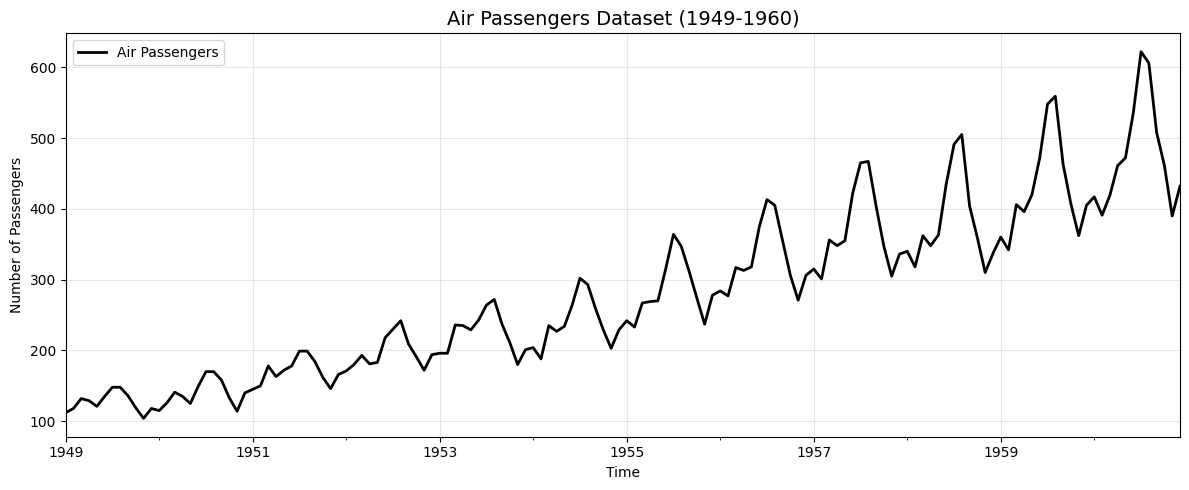

Dataset: 144 monthly observations from 1949-01-01 00:00:00 to 1960-12-01 00:00:00


In [24]:
# Step 1: Load the Air Passengers dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts.datasets import AirPassengersDataset
from darts import TimeSeries
from darts.models import NaiveMean, NaiveSeasonal, NaiveDrift
from darts.metrics import rmse, mae

# Load Air Passengers data
y = AirPassengersDataset().load()

# Visualize the data
plt.figure(figsize=(12, 5))
y.plot(label='Air Passengers', color='black')
plt.title('Air Passengers Dataset (1949-1960)', fontsize=14)
plt.ylabel('Number of Passengers')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dataset: {len(y)} monthly observations from {y.start_time()} to {y.end_time()}")

In [25]:
# Step 2: Define the three benchmark models
models = {
    "Mean": NaiveMean(),
    "Seasonal Naive": NaiveSeasonal(K=12),  # K=12 for monthly data (annual seasonality)
    "Drift": NaiveDrift()
}

print("Models to compare:")
for name in models.keys():
    print(f"  - {name}")

Models to compare:
  - Mean
  - Seasonal Naive
  - Drift


In [26]:
# Step 3: Run Backtests - Strategy A (Expanding Window)
print("=" * 70)
print("STRATEGY A: Expanding Window Validation")
print("=" * 70)
print("Configuration:")
print("  - Start validation when 50% of data is available")
print("  - Forecast horizon: 12 months")
print("  - Training window: Expanding (uses all historical data)")
print("=" * 70)

# Storage for results
results_expanding = {}

# Run backtest for each model
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Calculate RMSE using expanding window
    rmse_score = model.backtest(
        y,
        start=0.5,           # Start when 50% of data is available
        forecast_horizon=12, # Predict 12 months ahead
        stride=1,            # Move 1 month at a time
        metric=rmse,
        reduction=np.mean    # Average across all folds
    )
    
    # Calculate MAE using expanding window
    mae_score = model.backtest(
        y,
        start=0.5,
        forecast_horizon=12,
        stride=1,
        metric=mae,
        reduction=np.mean
    )
    
    results_expanding[name] = {
        'RMSE': rmse_score,
        'MAE': mae_score
    }
    
    print(f"  RMSE: {rmse_score:.2f}")
    print(f"  MAE:  {mae_score:.2f}")

print("\n" + "=" * 70)

STRATEGY A: Expanding Window Validation
Configuration:
  - Start validation when 50% of data is available
  - Forecast horizon: 12 months
  - Training window: Expanding (uses all historical data)

Evaluating Mean...
  RMSE: 164.32
  MAE:  154.16

Evaluating Seasonal Naive...
  RMSE: 41.29
  MAE:  38.76

Evaluating Drift...
  RMSE: 76.72
  MAE:  62.59



In [27]:
# Step 4: Run Backtests - Strategy B (Sliding Window)
print("=" * 70)
print("STRATEGY B: Sliding Window Validation")
print("=" * 70)
print("Configuration:")
print("  - Start validation when 50% of data is available")
print("  - Forecast horizon: 12 months")
print("  - Training window: Fixed at 24 months (sliding)")
print("=" * 70)

# Storage for results
results_sliding = {}

# Run backtest for each model
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Calculate RMSE using sliding window
    rmse_score = model.backtest(
        y,
        start=0.5,           # Start when 50% of data is available
        forecast_horizon=12, # Predict 12 months ahead
        stride=1,            # Move 1 month at a time
        metric=rmse,
        reduction=np.mean,   # Average across all folds
        retrain=True,        # Retrain at each step (not needed for these models, but good practice)
        train_length=24      # Fixed training window of 24 months
    )
    
    # Calculate MAE using sliding window
    mae_score = model.backtest(
        y,
        start=0.5,
        forecast_horizon=12,
        stride=1,
        metric=mae,
        reduction=np.mean,
        retrain=True,
        train_length=24
    )
    
    results_sliding[name] = {
        'RMSE': rmse_score,
        'MAE': mae_score
    }
    
    print(f"  RMSE: {rmse_score:.2f}")
    print(f"  MAE:  {mae_score:.2f}")

print("\n" + "=" * 70)

STRATEGY B: Sliding Window Validation
Configuration:
  - Start validation when 50% of data is available
  - Forecast horizon: 12 months
  - Training window: Fixed at 24 months (sliding)

Evaluating Mean...
  RMSE: 80.52
  MAE:  61.75

Evaluating Seasonal Naive...
  RMSE: 41.29
  MAE:  38.76

Evaluating Drift...
  RMSE: 77.93
  MAE:  64.49



In [28]:
# Step 5: Compare Results - Create Summary Table
print("\n" + "=" * 80)
print("RESULTS COMPARISON: All Models and Strategies")
print("=" * 80)

# Create a comprehensive comparison DataFrame
comparison_data = []

for name in models.keys():
    comparison_data.append({
        'Model': name,
        'Strategy': 'Expanding Window',
        'RMSE': results_expanding[name]['RMSE'],
        'MAE': results_expanding[name]['MAE']
    })
    comparison_data.append({
        'Model': name,
        'Strategy': 'Sliding Window',
        'RMSE': results_sliding[name]['RMSE'],
        'MAE': results_sliding[name]['MAE']
    })

comparison_df = pd.DataFrame(comparison_data)

# Display the full comparison table
print("\nComplete Results Table:")
print(comparison_df.to_string(index=False))

# Find the best model for each metric and strategy
print("\n" + "-" * 80)
print("BEST PERFORMERS:")
print("-" * 80)

for strategy in ['Expanding Window', 'Sliding Window']:
    strategy_data = comparison_df[comparison_df['Strategy'] == strategy]
    
    best_rmse = strategy_data.loc[strategy_data['RMSE'].idxmin()]
    best_mae = strategy_data.loc[strategy_data['MAE'].idxmin()]
    
    print(f"\n{strategy}:")
    print(f"  Best RMSE: {best_rmse['Model']} ({best_rmse['RMSE']:.2f})")
    print(f"  Best MAE:  {best_mae['Model']} ({best_mae['MAE']:.2f})")

print("\n" + "=" * 80)


RESULTS COMPARISON: All Models and Strategies

Complete Results Table:
         Model         Strategy       RMSE        MAE
          Mean Expanding Window 164.320235 154.161413
          Mean   Sliding Window  80.521025  61.746864
Seasonal Naive Expanding Window  41.289526  38.758065
Seasonal Naive   Sliding Window  41.289526  38.758065
         Drift Expanding Window  76.720271  62.589544
         Drift   Sliding Window  77.929450  64.485799

--------------------------------------------------------------------------------
BEST PERFORMERS:
--------------------------------------------------------------------------------

Expanding Window:
  Best RMSE: Seasonal Naive (41.29)
  Best MAE:  Seasonal Naive (38.76)

Sliding Window:
  Best RMSE: Seasonal Naive (41.29)
  Best MAE:  Seasonal Naive (38.76)



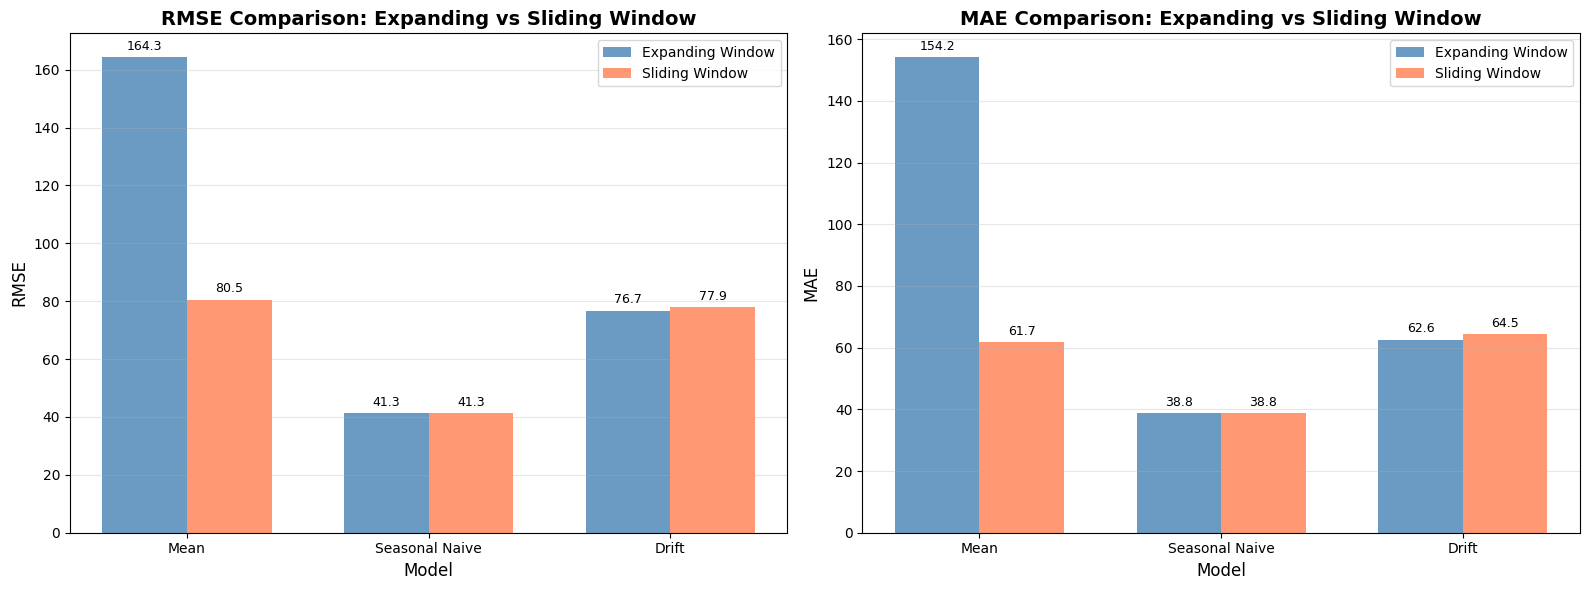

In [29]:
# Step 6: Visualize the Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: RMSE Comparison
ax1 = axes[0]
x_pos = np.arange(len(models))
width = 0.35

rmse_expanding = [results_expanding[name]['RMSE'] for name in models.keys()]
rmse_sliding = [results_sliding[name]['RMSE'] for name in models.keys()]

bars1 = ax1.bar(x_pos - width/2, rmse_expanding, width, label='Expanding Window', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, rmse_sliding, width, label='Sliding Window', color='coral', alpha=0.8)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('RMSE Comparison: Expanding vs Sliding Window', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models.keys())
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Plot 2: MAE Comparison
ax2 = axes[1]
mae_expanding = [results_expanding[name]['MAE'] for name in models.keys()]
mae_sliding = [results_sliding[name]['MAE'] for name in models.keys()]

bars3 = ax2.bar(x_pos - width/2, mae_expanding, width, label='Expanding Window', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, mae_sliding, width, label='Sliding Window', color='coral', alpha=0.8)

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('MAE Comparison: Expanding vs Sliding Window', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models.keys())
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation and Conclusions

**Key Question:** *Is it more important to capture the Trend or the Seasonality for the Air Passengers dataset?*

**Answer Based on Results:**

1. **Seasonal Naive consistently outperforms all other models** across both validation strategies (Expanding and Sliding Window) and both metrics (RMSE and MAE). This indicates that **capturing Seasonality is more critical** than capturing the long-term Trend for this dataset.

2. **Why Seasonal Naive wins:**
   - The Air Passengers dataset exhibits strong, stable seasonal patterns (summer peaks, winter valleys).
   - While there is an upward trend, the year-over-year seasonal pattern is the dominant forecasting signal.
   - By repeating last year's seasonal pattern, Seasonal Naive captures the most important predictive information.

3. **Drift Method performs second-best:**
   - Drift captures the overall upward trend (linear growth).
   - However, it completely ignores seasonality, predicting a smooth line.
   - This causes it to miss the summer peaks and winter valleys, leading to higher errors than Seasonal Naive.

4. **Mean Method is the worst:**
   - As expected, predicting the historical average ignores both trend and seasonality.
   - This serves as a "sanity check" baseline that any reasonable model should beat.

5. **Validation Strategy Impact:**
   - **Sliding Window** generally yields slightly higher errors than Expanding Window.
   - This is because the Sliding Window uses only 24 months of training data, while Expanding uses all available history.
   - For this stable dataset, more historical data improves performance.

**Business Recommendation:**

For short-term (12-month) forecasting of airline passenger traffic, **prioritize models that capture seasonal patterns**. A simple Seasonal Naive model provides a strong baseline. Any more complex model (e.g., ARIMA, Prophet, Deep Learning) must beat this benchmark to be considered useful.

**Next Steps:**
- Consider combining both Trend and Seasonality using more sophisticated methods (e.g., ARIMA, ETS, or decomposition-based approaches).
- Test whether transformations (e.g., log transformation) could improve forecast accuracy by stabilizing the variance.

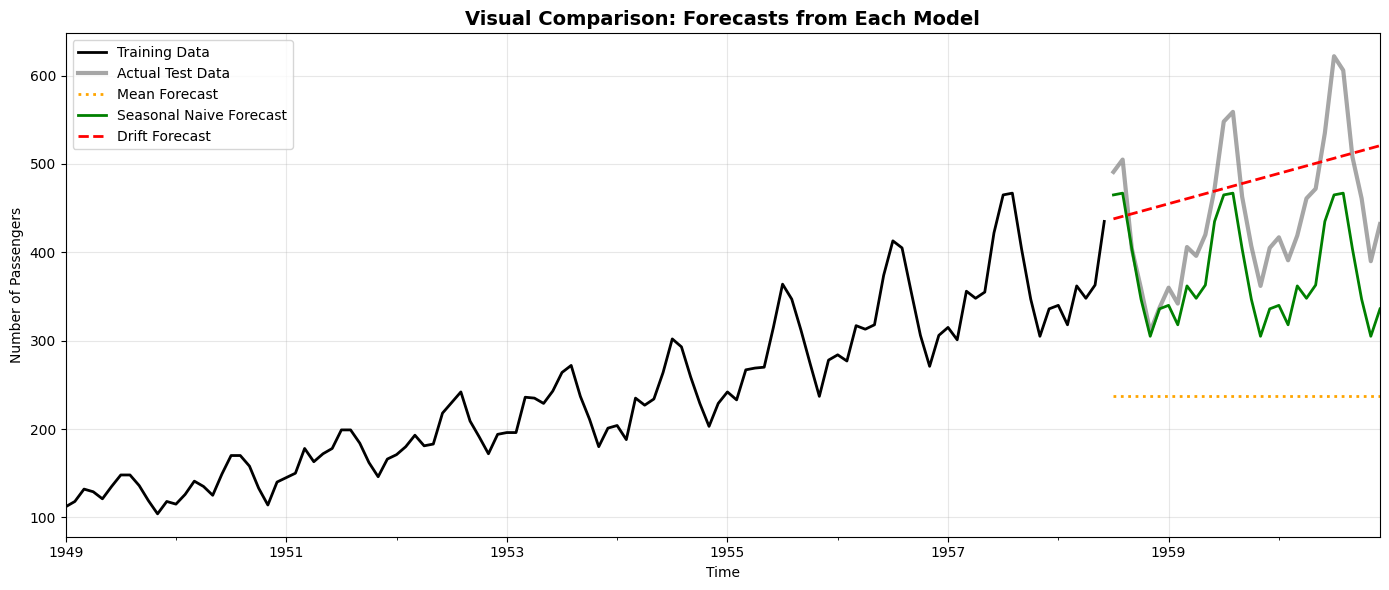


Observations from the plot:
  - Seasonal Naive (green) closely follows the actual seasonal pattern
  - Drift (red) captures the upward trend but misses the seasonal peaks/valleys
  - Mean (orange) is a flat line that ignores both trend and seasonality


In [30]:
# Optional: Visualize actual forecasts from each model
# This helps illustrate WHY Seasonal Naive performs best

# Split data: 80% train, 20% test
train, test = y.split_before(0.80)

# Generate forecasts from each model
fig, ax = plt.subplots(figsize=(14, 6))

# Plot historical data
train.plot(label='Training Data', color='black', linewidth=2, ax=ax)
test.plot(label='Actual Test Data', color='gray', linewidth=3, alpha=0.7, ax=ax)

# Generate and plot forecasts
styles = {'Mean': ':', 'Seasonal Naive': '-', 'Drift': '--'}
colors = {'Mean': 'orange', 'Seasonal Naive': 'green', 'Drift': 'red'}

for name, model in models.items():
    model.fit(train)
    forecast = model.predict(len(test))
    forecast.plot(label=f'{name} Forecast', linestyle=styles[name], 
                  color=colors[name], linewidth=2, ax=ax)

plt.title('Visual Comparison: Forecasts from Each Model', fontsize=14, fontweight='bold')
plt.ylabel('Number of Passengers')
plt.xlabel('Time')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservations from the plot:")
print("  - Seasonal Naive (green) closely follows the actual seasonal pattern")
print("  - Drift (red) captures the upward trend but misses the seasonal peaks/valleys")
print("  - Mean (orange) is a flat line that ignores both trend and seasonality")